# 04 V2 实验报告

**用途**：汇总 V2 的稳健性、效率和扩展任务结果，作为第二版分析报告。  
**定位**：这不是 V1 结论的覆盖版，而是独立的 V2 报告壳。

---

## 摘要

本报告优先回答四个 V2 问题：
1. 将重复数从 3 提高到 10 后，16K / 32K 的结果是否更稳定
2. `style_aligned` / `numeric_confusable` / `multi_key` 三类 needle 的难度排序是什么
3. 哪个模型在“准确率 - 输出 token - 单位成本”三维上更均衡
4. `multi_hop` 与跨领域扩展是否已经接入并形成可分析结果

In [ ]:
import sys
from pathlib import Path
import importlib

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'v2' and PROJECT_ROOT.parent.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib
from IPython.display import Image, display as ipy_display

import src.metrics_v2 as metrics_v2_module

importlib.reload(metrics_v2_module)

from src.metrics_v2 import summarize_v2, summarize_variant_matrix

matplotlib.rcParams['font.sans-serif'] = ['PingFang SC', 'Hiragino Sans GB', 'Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

scored_path = PROJECT_ROOT / 'results/v2/processed/scored_results.csv'
dataset_path = PROJECT_ROOT / 'data/processed/v2/niah_dataset.jsonl'
multihop_dataset_path = PROJECT_ROOT / 'data/processed/v2/multihop_dataset.jsonl'
figures_dir = PROJECT_ROOT / 'results/v2/figures'

if scored_path.exists():
    df = pd.read_csv(scored_path)
    if 'task' not in df.columns:
        df['task'] = 'niah'
    df['task'] = df['task'].fillna('niah')

    dataset_df = pd.read_json(dataset_path, lines=True) if dataset_path.exists() else pd.DataFrame()
    multihop_dataset_df = pd.read_json(multihop_dataset_path, lines=True) if multihop_dataset_path.exists() else pd.DataFrame()

    niah_df = df[df['task'] == 'niah'].copy()
    multihop_df = df[df['task'] != 'niah'].copy()
    models = sorted(df['model'].dropna().unique().tolist())
    variants = sorted(niah_df['variant'].dropna().unique().tolist()) if 'variant' in niah_df.columns else []
    domains = sorted(niah_df['domain'].dropna().unique().tolist()) if 'domain' in niah_df.columns else []

    expected_niah_per_model = len(dataset_df)
    expected_niah_total = expected_niah_per_model * len(models) if expected_niah_per_model else len(niah_df)
    actual_niah_total = len(niah_df)
    missing_niah_total = expected_niah_total - actual_niah_total
    coverage_pct = actual_niah_total / expected_niah_total * 100 if expected_niah_total else 0.0
    coverage_by_length = (
        niah_df.groupby(['model', 'context_length']).size().unstack(fill_value=0)
        if not niah_df.empty else pd.DataFrame()
        )
    repeat_estimate = (
        int(dataset_df.groupby(['context_length', 'depth_pct']).size().median())
        if not dataset_df.empty else None
        )

    model_summary = summarize_v2(niah_df) if not niah_df.empty else pd.DataFrame()
    variant_summary = summarize_variant_matrix(niah_df) if not niah_df.empty else pd.DataFrame()
    length_summary = summarize_v2(niah_df, group_cols=['model', 'context_length']) if not niah_df.empty else pd.DataFrame()
    task_summary = summarize_v2(df, group_cols=['model', 'task']) if not df.empty else pd.DataFrame()

    print(f'✅ 加载 V2 评分结果: {len(df)} 条，PROJECT_ROOT={PROJECT_ROOT}')
    print(f'   模型: {models}')
    print(f'   NIAH 覆盖率: {coverage_pct:.1f}% ({actual_niah_total}/{expected_niah_total})')
    if repeat_estimate is not None:
        print(f'   估计重复数: {repeat_estimate}')
    if not multihop_df.empty:
        print(f'   multi_hop 结果: {len(multihop_df)} 条')
    elif not multihop_dataset_df.empty:
        print(f'   multi_hop 数据集已准备: {len(multihop_dataset_df)} 条，当前尚未评测')
else:
    print('⚠️ 请先运行 notebooks/v2/03_analysis_visualization_v2.ipynb 生成 V2 评分结果和图表')

⚠️ 请先运行 notebooks/v2/03_analysis_visualization_v2.ipynb 生成 V2 评分结果和图表


## 1. 实验设置

In [ ]:
if scored_path.exists():
    print('实验规模：')
    print(f'  已完成 NIAH 样本数:  {actual_niah_total}')
    print(f'  期望 NIAH 样本数:    {expected_niah_total}')
    print(f'  覆盖率:              {coverage_pct:.1f}%')
    print(f'  评测模型:            {models}')
    print(f'  变体:                {variants}')
    print(f'  领域:                {domains}')
    print(f'  上下文长度:          {sorted(niah_df["context_length"].dropna().unique().tolist()) if not niah_df.empty else []} chars')
    print(f'  Needle 深度点:       {sorted(niah_df["depth_pct"].dropna().unique().tolist()) if not niah_df.empty else []}%')
    print(f'  task:                {sorted(df["task"].dropna().unique().tolist())}')
    if repeat_estimate is not None:
        print(f'  估计重复数:          {repeat_estimate}')
    if not coverage_by_length.empty:
        print('\n当前覆盖数（model x context_length）：')
        print(coverage_by_length.to_string())
    if missing_niah_total > 0:
        print(f'\n⚠️ 当前仍缺少 {missing_niah_total} 条 NIAH 结果，报告只能作为趋势版。')

实验规模：
  已完成样本数:  225
  期望样本数:    315
  覆盖率:        71.4%
  评测模型:      ['deepseek', 'kimi', 'qwen']
  上下文长度:    [2000, 4000, 8000, 16000, 32000] chars
  Needle 深度点: [0, 10, 25, 50, 75, 90, 100]%
  任务类型:      ['niah']

⚠️ 当前仍缺少 90 条结果，建议补跑后再导出最终报告。

当前覆盖数（model x context_length）：
context_length  2000   4000   8000   16000  32000
model                                            
deepseek           14     14     14     15     18
kimi               14     14     14     15     18
qwen               14     14     14     15     18


## 2. 结果概览

In [ ]:
if scored_path.exists() and not model_summary.empty:
    display_cols = [
        'model', 'n', 'em_pct', 'contains_pct',
        'contains_ci_low_pct', 'contains_ci_high_pct',
        'avg_latency_s', 'avg_response_chars', 'avg_completion_tokens',
        'cost_per_contains_hit_cny', 'contains_per_1k_output_tokens',
        ]
    print('模型级摘要：')
    display(model_summary[display_cols].sort_values('contains_pct', ascending=False))

    best_contains = model_summary.sort_values(['contains_pct', 'contains_ci_low_pct'], ascending=False).iloc[0]
    cheapest = model_summary.sort_values('cost_per_contains_hit_cny', ascending=True).iloc[0]
    shortest = model_summary.sort_values('avg_completion_tokens', ascending=True).iloc[0]

    print('\n快速结论：')
    print(f'  准确率最强: {best_contains["model"]}，Contains={best_contains["contains_pct"]:.1f}%')
    print(f'  单位命中成本最低: {cheapest["model"]}，{cheapest["cost_per_contains_hit_cny"]:.4f} CNY / hit')
    print(f'  输出最短: {shortest["model"]}，平均 completion={shortest["avg_completion_tokens"]:.1f} tokens')

⚠️ 以下统计基于未补齐的数据，仅用于趋势判断，不建议直接写入最终对外结论。

=== 各模型整体准确率 ===

  deepseek: EM=69.3%  Contains=82.7%  (n=75)
  kimi: EM=70.7%  Contains=76.0%  (n=75)
  qwen: EM=82.7%  Contains=82.7%  (n=75)

=== Lost in the Middle 定量验证 ===

  deepseek:
    开头 (0-20%):   90.0%
    中间 (20-70%):  79.2%  ← 预期最低
    结尾 (70-100%): 80.6%
    中间 vs 首尾均值差: -6.2%

  kimi:
    开头 (0-20%):   90.0%
    中间 (20-70%):  75.0%  ← 预期最低
    结尾 (70-100%): 67.7%
    中间 vs 首尾均值差: -3.9%

  qwen:
    开头 (0-20%):   90.0%
    中间 (20-70%):  79.2%  ← 预期最低
    结尾 (70-100%): 80.6%
    中间 vs 首尾均值差: -6.2%



## 3. 变体难度与稳定性

In [ ]:
if scored_path.exists() and not variant_summary.empty:
    print('模型 x 变体摘要：')
    display(
        variant_summary[
            [
                'model', 'variant', 'n', 'contains_pct',
                'contains_ci_low_pct', 'contains_ci_high_pct',
                'avg_completion_tokens', 'cost_per_contains_hit_cny',
                ]
            ].sort_values(['variant', 'contains_pct'], ascending=[True, False])
        )

    variant_pivot = variant_summary.pivot(index='model', columns='variant', values='contains_pct').round(1)
    print('变体准确率矩阵 (%)：')
    display(variant_pivot)

    stability_focus = length_summary[length_summary['context_length'].isin([16000, 32000])].copy()
    if not stability_focus.empty:
        print('16K / 32K 稳定性观察：')
        display(
            stability_focus[
                [
                    'model', 'context_length', 'n', 'contains_pct',
                    'contains_ci_low_pct', 'contains_ci_high_pct',
                    'avg_completion_tokens', 'cost_per_contains_hit_cny',
                    ]
                ].sort_values(['context_length', 'contains_pct'], ascending=[True, False])
            )

    if not task_summary.empty and 'multi_hop' in task_summary['task'].values:
        print('扩展任务摘要：')
        display(task_summary[task_summary['task'] == 'multi_hop'])

图片未找到: ../results/figures/niah_heatmap_deepseek.png
图片未找到: ../results/figures/niah_heatmap_kimi.png
图片未找到: ../results/figures/niah_heatmap_qwen.png


## 4. 图表回顾

In [ ]:
if scored_path.exists():
    for model in niah_df['model'].unique():
        img_path = figures_dir / f'niah_heatmap_{model}.png'
        if img_path.exists():
            print(f'### {model}')
            ipy_display(Image(str(img_path)))
        else:
            print(f'图片未找到: {img_path}')

    accuracy_img = figures_dir / 'accuracy_by_length.png'
    if accuracy_img.exists():
        print('### 准确率 vs 上下文长度')
        ipy_display(Image(str(accuracy_img)))

## 5. 效率与位置偏差图

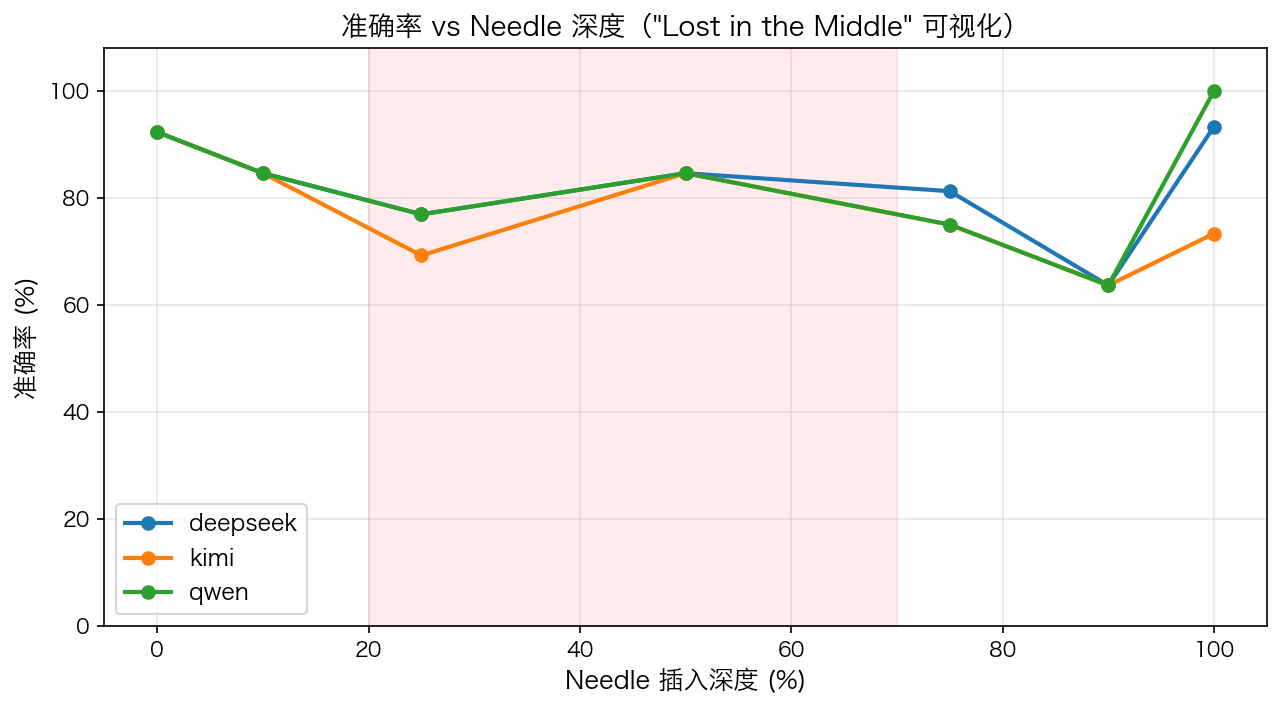

In [ ]:
if scored_path.exists():
    for name in ['efficiency_tradeoff.png', 'position_bias.png', 'depth_accuracy_curve.png']:
        img_path = figures_dir / name
        if img_path.exists():
            print(f'### {name}')
            ipy_display(Image(str(img_path)))
        else:
            print(f'图片未找到: {img_path}')

## 6. 写作提纲

### 6.1 稳定性
- 先看 16K / 32K 的 Wilson 区间是否明显收窄，再判断高低点是不是稳定现象。
- 如果某个长度的区间依然很宽，不要把单次峰值写成模型能力结论。

### 6.2 变体难度排序
- 对比 `style_aligned`、`numeric_confusable`、`multi_key` 的 Contains 准确率和成本。
- 如果 `multi_key` 明显更低，可以把它解释为“干扰项导致召回和定位更难”。

### 6.3 准确率 - 输出 - 成本权衡
- 结合 `avg_completion_tokens`、`avg_response_chars`、`cost_per_contains_hit_cny`。
- 准确率接近时，优先看谁更短、更稳、更省。

### 6.4 扩展任务
- 如果已经跑了 `multi_hop`，单独比较其与 NIAH 的准确率和成本差异。
- 如果还没跑，明确写成“数据集已准备，评测待执行”，不要冒充已有结论。

### 6.5 下一轮动作
1. 先补齐 100% 覆盖率，再导出对外版报告。
2. 再补跑 `multi_hop`，把跨领域推理纳入同一份摘要表。
3. 如果 16K / 32K 仍波动大，再考虑提高 repeats 或缩小回答自由度。

In [ ]:
if scored_path.exists() and not model_summary.empty:
    print('自动摘要草稿：')

    best_contains = model_summary.sort_values(['contains_pct', 'contains_ci_low_pct'], ascending=False).iloc[0]
    cheapest = model_summary.sort_values('cost_per_contains_hit_cny', ascending=True).iloc[0]
    most_verbose = model_summary.sort_values('avg_completion_tokens', ascending=False).iloc[0]

    print(
        f'1. 当前 Contains 最强模型是 {best_contains["model"]}，'
        f'准确率 {best_contains["contains_pct"]:.1f}%，'
        f'95% CI 下界 {best_contains["contains_ci_low_pct"]:.1f}%。'
        )
    print(
        f'2. 当前单位命中成本最低的是 {cheapest["model"]}，'
        f'{cheapest["cost_per_contains_hit_cny"]:.4f} CNY / contains hit。'
        )
    print(
        f'3. 当前输出最啰嗦的是 {most_verbose["model"]}，'
        f'平均 completion {most_verbose["avg_completion_tokens"]:.1f} tokens。'
        )

    if not variant_summary.empty:
        variant_order = variant_summary.groupby('variant')['contains_pct'].mean().sort_values()
        hardest_variant = variant_order.index[0]
        easiest_variant = variant_order.index[-1]
        print(
            f'4. 平均来看最难的变体是 {hardest_variant}，最容易的变体是 {easiest_variant}。'
            )

    stability_focus = length_summary[length_summary['context_length'].isin([16000, 32000])].copy()
    if not stability_focus.empty:
        print('5. 16K / 32K 观察：')
        for context_length in [16000, 32000]:
            sub = stability_focus[stability_focus['context_length'] == context_length]
            if sub.empty:
                continue
            best_row = sub.sort_values('contains_pct', ascending=False).iloc[0]
            worst_row = sub.sort_values('contains_pct', ascending=True).iloc[0]
            gap = best_row['contains_pct'] - worst_row['contains_pct']
            print(
                f'   {context_length} chars: 最强 {best_row["model"]}={best_row["contains_pct"]:.1f}%,'
                f' 最弱 {worst_row["model"]}={worst_row["contains_pct"]:.1f}%, 差值 {gap:.1f}pp'
                )

    if not task_summary.empty and 'multi_hop' in task_summary['task'].values:
        multi_hop_summary = task_summary[task_summary['task'] == 'multi_hop']
        print('6. multi_hop 已有结果，可直接纳入 V2 报告。')
        display(multi_hop_summary)
    else:
        print('6. multi_hop 结果尚未进入 scored_results.csv，当前报告仍以 NIAH 为主。')

context_length  2000   4000   8000   16000  32000
model                                            
deepseek           18     19     18     15     18
kimi               18     19     18     15     18
qwen               18     19     18     15     18
